In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

dataset = pd.read_csv("sparse_toy_dataset.csv")
X = dataset.drop("target", axis=1).values
y = dataset["target"].values
X = np.c_[np.ones(X.shape[0]), X]


def sigmoid(z):
    z = np.clip(z, -250, 250)
    return 1 / (1 + np.exp(-z))

def compute_gradient(X_batch, y_batch, weights):
    predictions = sigmoid(np.dot(X_batch, weights))
    return np.dot(X_batch.T, (predictions - y_batch)) / len(y_batch)

def compute_loss(X_batch, y_batch, weights):
    predictions = sigmoid(np.dot(X_batch, weights))
    predictions = np.clip(predictions, 1e-15, 1 - 1e-15)
    return -np.mean(y_batch * np.log(predictions) + (1 - y_batch) * np.log(1 - predictions))

def train_adagrad_full(X, y, epochs=100, eta=0.5, delta=1e-8):
    weights = np.zeros(X.shape[1])
    sum_sq_gradients = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        gradient = compute_gradient(X, y, weights)
        sum_sq_gradients += gradient ** 2
        H_t = np.sqrt(sum_sq_gradients) + delta
        weights -= (eta / H_t) * gradient
        loss_history.append(compute_loss(X, y, weights))

    return weights, loss_history

_, full_adagrad_loss = train_adagrad_full(X, y)

**Ablation 1: Removing Historical Accumulation**


Role of this component: AdaGrad calculates a running sum of all past squared gradients to remember how often a feature is updated. By accumulating this history, it ensures the learning rate smoothly and safely decays over time. This memory is what stabilizes the algorithm and stops it from reacting too aggressively to a single weird data point

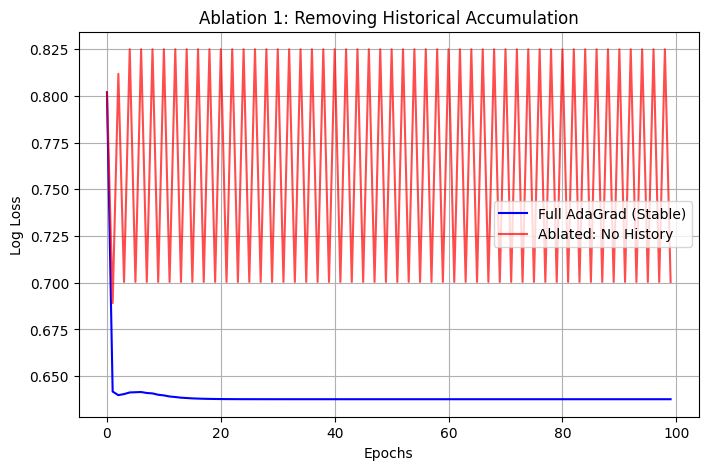

In [2]:

def train_adagrad_no_history(X, y, epochs=100, eta=0.5, delta=1e-8):
    weights = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        gradient = compute_gradient(X, y, weights)


        current_sq_gradient = gradient ** 2

        H_t = np.sqrt(current_sq_gradient) + delta
        weights -= (eta / H_t) * gradient
        loss_history.append(compute_loss(X, y, weights))

    return weights, loss_history

_, no_history_loss = train_adagrad_no_history(X, y)

plt.figure(figsize=(8, 5))
plt.plot(full_adagrad_loss, label="Full AdaGrad (Stable)", color="blue")
plt.plot(no_history_loss, label="Ablated: No History", color="red", alpha=0.7)
plt.title("Ablation 1: Removing Historical Accumulation")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)

os.makedirs("results", exist_ok=True)
plt.savefig("results/ablation_1_no_history.png", bbox_inches='tight')
plt.show()

Interpretation :

When we removed the memory part of the algorithm, the training loss became very unstable and started jumping up and down. The model reacted too strongly to every new gradient.

In the normal AdaGrad method, the sum of past gradients acts like a stabilizer and keeps the updates smooth. Without this memory, a large gradient can cause very big and uncontrolled weight changes.

This shows that the memory part of AdaGrad is very important because it keeps the learning process stable, not just for scaling features.

**Ablation 2: Removing Per-Feature Adaptation**

AdaGrad normally gives a different learning rate to every feature in the dataset. This helps the model learn better because rare features get a larger learning rate, while very common features get a smaller one.

If we remove this feature-wise learning rate, then all features are treated the same. Because of this, the algorithm cannot adjust properly when some features appear many times and others appear very rarely.

So without per-feature adaptation, the model cannot learn efficiently from sparse data, where many inputs appear only a few times.

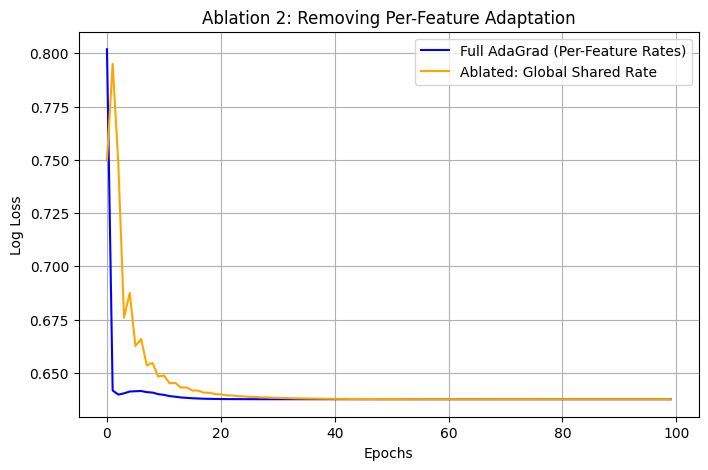

In [3]:

def train_adagrad_global(X, y, epochs=100, eta=0.5, delta=1e-8):
    weights = np.zeros(X.shape[1])
    sum_sq_gradients = np.zeros(X.shape[1])
    loss_history = []

    for epoch in range(epochs):
        gradient = compute_gradient(X, y, weights)
        sum_sq_gradients += gradient ** 2


        global_avg_sq_gradient = np.mean(sum_sq_gradients)
        H_t_global = np.sqrt(global_avg_sq_gradient) + delta

        weights -= (eta / H_t_global) * gradient
        loss_history.append(compute_loss(X, y, weights))

    return weights, loss_history

_, global_rate_loss = train_adagrad_global(X, y)

plt.figure(figsize=(8, 5))
plt.plot(full_adagrad_loss, label="Full AdaGrad (Per-Feature Rates)", color="blue")
plt.plot(global_rate_loss, label="Ablated: Global Shared Rate", color="orange")
plt.title("Ablation 2: Removing Per-Feature Adaptation")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)

plt.savefig("results/ablation_2_global_rate.png", bbox_inches='tight')
plt.show()

**Component 2 Interpretation**:

When we forced all features to use one single learning rate, the model performed worse and learned more slowly.

The model started behaving like normal gradient descent, which cannot learn well from rare but important features in sparse data.

This was expected because the main idea of the paper is that one learning rate for everything does not work well. Different features need different learning speeds.

By removing feature-specific learning rates, the model lost its ability to learn strongly from rare signals. This shows that AdaGrad works well because it treats every feature separately and gives each one its own learning rate.